# This `ipynb` file serves the purpose to check our experimentations' results.

---
---

## 1. Create a combined CSV of the outputs

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os

# Find CSV in output/ and sub-folders
csv_files = list(Path('../output').rglob('*.csv'))

# Combine CSV
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Sort CSV by ['dataset', 'classifier']
df = df.sort_values(['dataset', 'classifier'], ascending=True).reset_index(drop=True)

df['total_time'] = df['train_time'] + df['test_time'] + df['generate_kernel_time'] + df['apply_kernel_on_train_time'] + df['apply_kernel_on_test_time']

# Display
display(df.head(20))

# Save
#df.to_csv('combined_results.csv', index=False)

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
1,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681
2,2026-04-01 19:57:16,0,mlp_MultiRocket_49728,49728,InsectWingbeatSound,-1,2.418536,0.623737,0.215926,0.027849,0.097553,0.866504,0.000065,0.000422,10,10,4,0,17.0,3.626368
3,2026-04-01 17:20:28,0,skew_MultiRocket_62160,62160,InsectWingbeatSound,-1,1.930530,0.618687,0.363790,0.028366,0.105219,0.988746,0.000148,0.000409,10,10,4,0,17.0,3.416651
4,2026-04-01 17:19:54,0,var_MultiRocket_62160,62160,InsectWingbeatSound,-1,2.354961,0.626768,0.346386,0.027857,0.127582,0.940959,0.000122,0.000494,10,10,4,0,17.0,3.797745
5,2026-03-31 15:39:20,0,MultiRocket_10000,10000,StarLightCurves,-1,1.652332,0.979480,0.201358,0.031560,0.254880,2.047145,0.000915,0.008832,10,10,4,0,17.0,4.187275
6,2026-03-31 15:40:23,0,MultiRocket_49728,49728,StarLightCurves,-1,1.775467,0.979966,0.912552,0.081249,1.130735,9.515211,0.000897,0.007077,10,10,4,0,17.0,13.415214
7,2026-04-01 19:57:50,0,mlp_MultiRocket_49728,49728,StarLightCurves,-1,3.778009,0.977659,0.884660,0.079941,1.132263,9.331292,0.000899,0.007024,10,10,4,0,17.0,15.206165
8,2026-04-01 17:22:56,0,skew_MultiRocket_62160,62160,StarLightCurves,-1,4.206679,0.978752,1.814154,0.078431,1.412603,10.944484,0.001014,0.006871,10,10,4,0,17.0,18.456351
9,2026-04-01 17:22:01,0,var_MultiRocket_62160,62160,StarLightCurves,-1,2.590112,0.979723,1.739292,0.078023,1.324663,10.255112,0.000897,0.007092,10,10,4,0,17.0,15.987202


---
---

## 2. Our experiments' dataset infos

In [2]:
name = ["InsectWingbeatSound", "StarLightCurves", "ElectricDevices", "Crop"]
train = [220, 1000, 8926, 7200]
test = [1980, 8236, 7711, 16800]
total = [2200, 9236, 16637, 24000]

df_num = pd.DataFrame({'Name': name, 'Train': train, 'Test': test, 'Total': total})
display(df_num)

,Name,Train,Test,Total
0,InsectWingbeatSound,220,1980,2200
1,StarLightCurves,1000,8236,9236
2,ElectricDevices,8926,7711,16637
3,Crop,7200,16800,24000


---
---


# 3-1. Our first approach

We tried two times by adding a **5th pooling operator** : the variance and the skewness.  
Having now 62 160 features (84 * 74 * 2 * 5).

Here are the charts for `test_acc` and `total_time`.

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
1,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681
3,2026-04-01 17:20:28,0,skew_MultiRocket_62160,62160,InsectWingbeatSound,-1,1.930530,0.618687,0.363790,0.028366,0.105219,0.988746,0.000148,0.000409,10,10,4,0,17.0,3.416651
4,2026-04-01 17:19:54,0,var_MultiRocket_62160,62160,InsectWingbeatSound,-1,2.354961,0.626768,0.346386,0.027857,0.127582,0.940959,0.000122,0.000494,10,10,4,0,17.0,3.797745
5,2026-03-31 15:39:20,0,MultiRocket_10000,10000,StarLightCurves,-1,1.652332,0.979480,0.201358,0.031560,0.254880,2.047145,0.000915,0.008832,10,10,4,0,17.0,4.187275
6,2026-03-31 15:40:23,0,MultiRocket_49728,49728,StarLightCurves,-1,1.775467,0.979966,0.912552,0.081249,1.130735,9.515211,0.000897,0.007077,10,10,4,0,17.0,13.415214
8,2026-04-01 17:22:56,0,skew_MultiRocket_62160,62160,StarLightCurves,-1,4.206679,0.978752,1.814154,0.078431,1.412603,10.944484,0.001014,0.006871,10,10,4,0,17.0,18.456351
9,2026-04-01 17:22:01,0,var_MultiRocket_62160,62160,StarLightCurves,-1,2.590112,0.979723,1.739292,0.078023,1.324663,10.255112,0.000897,0.007092,10,10,4,0,17.0,15.987202


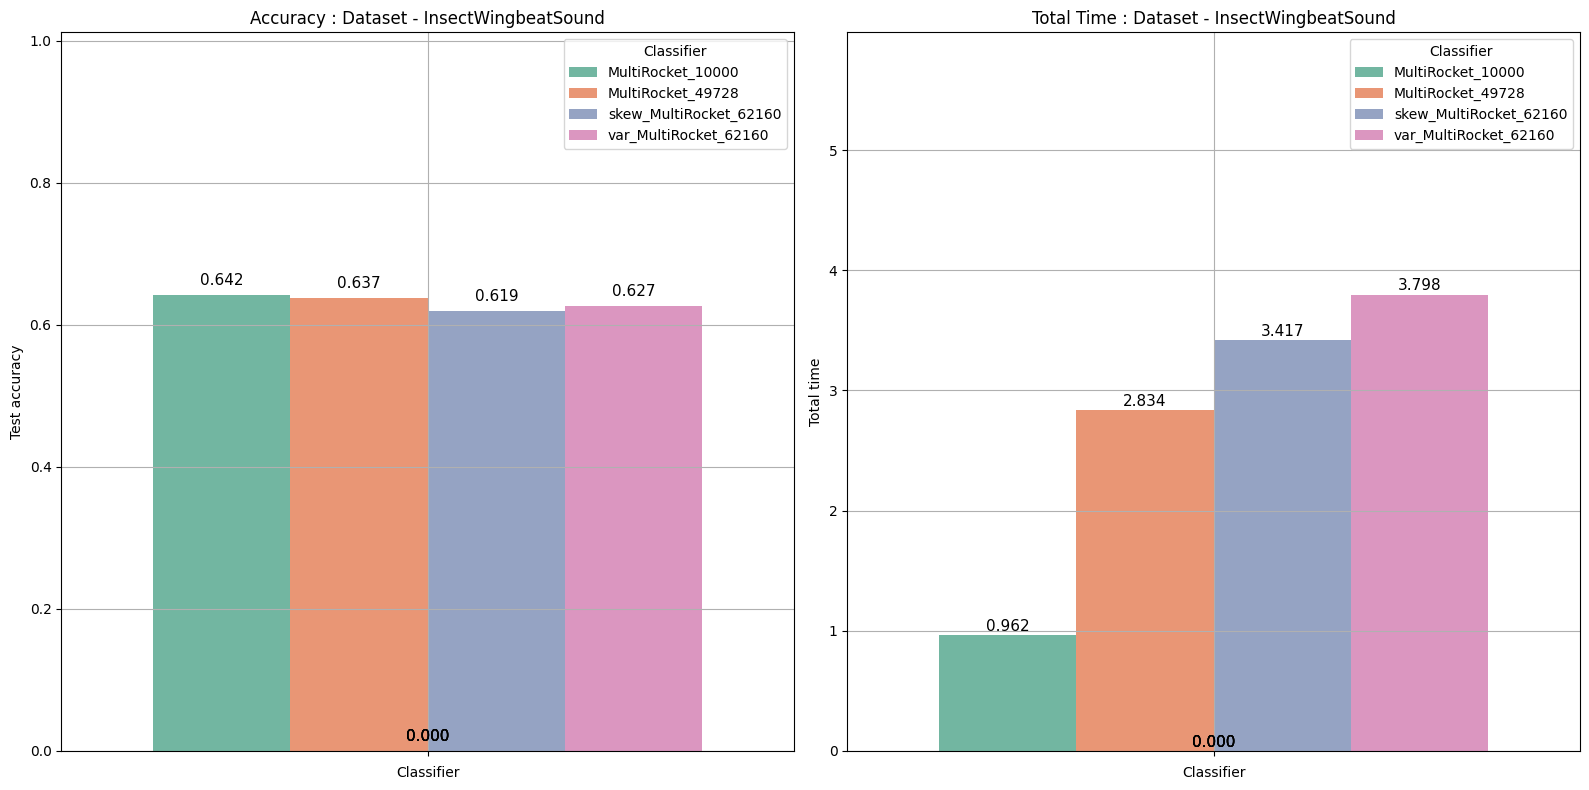

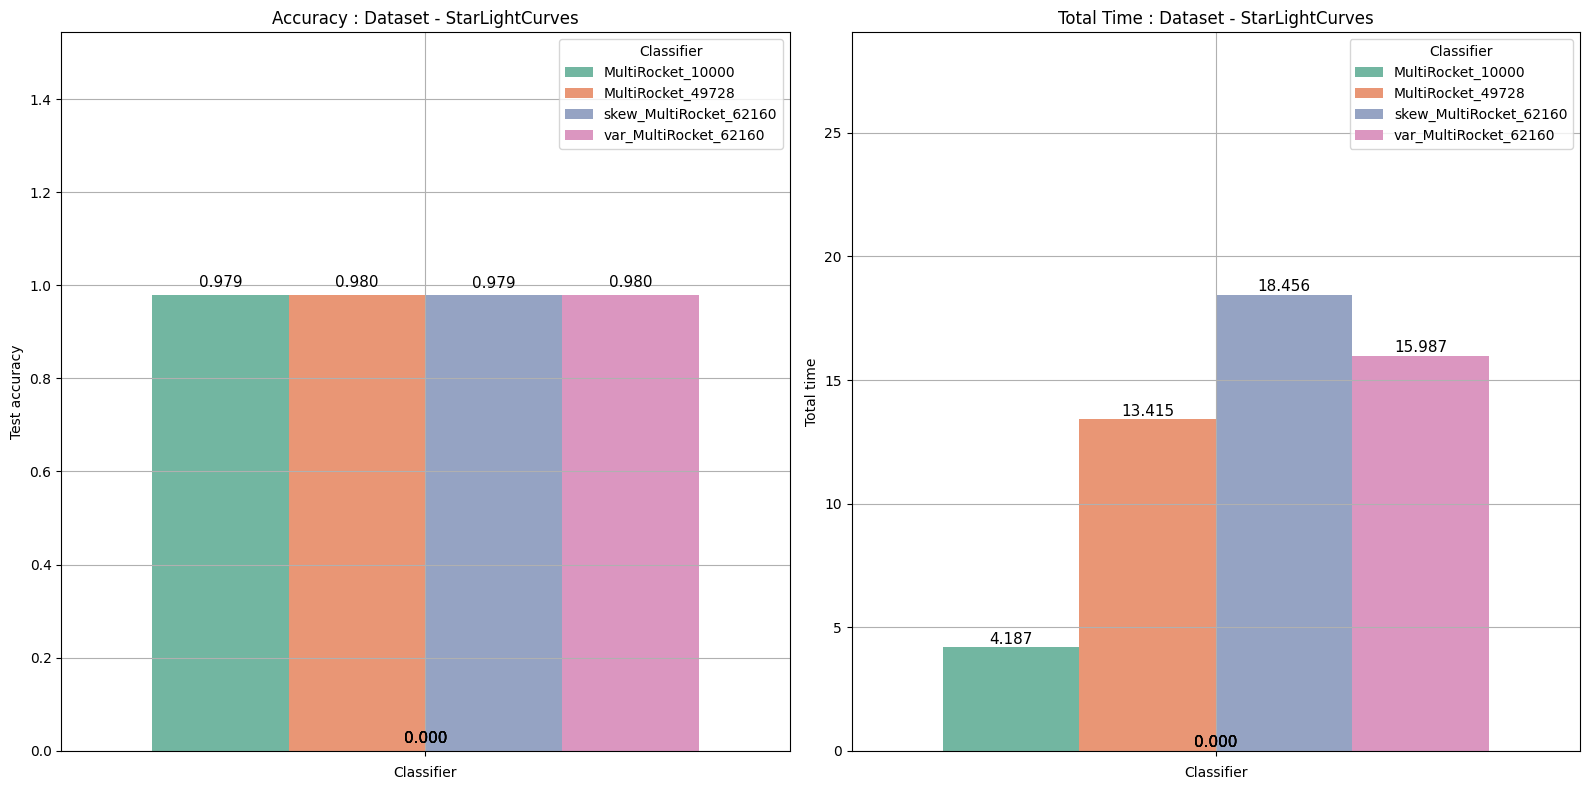

In [3]:
df_v1 = df.copy()

df_v1 = df_v1[~df_v1['classifier'].str.contains('mlp')]

# Display
display(df_v1.head(20))

for dataset in df_v1['dataset'].unique():

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v1[df_v1['dataset'] == dataset],
        y='test_acc',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Accuracy : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v1[df_v1['dataset'] == dataset],
        y='total_time',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Total Time : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.tight_layout()
    plt.show()

---
---


# 3-2. Our second approach

We tried two times by changing the `LogisticRegression()` by : a `MLPClassifier()` then a `RandomForestClassifier()` (TODO).

Here are the charts for `test_acc` and `total_time`.

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
1,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681
2,2026-04-01 19:57:16,0,mlp_MultiRocket_49728,49728,InsectWingbeatSound,-1,2.418536,0.623737,0.215926,0.027849,0.097553,0.866504,0.000065,0.000422,10,10,4,0,17.0,3.626368
5,2026-03-31 15:39:20,0,MultiRocket_10000,10000,StarLightCurves,-1,1.652332,0.979480,0.201358,0.031560,0.254880,2.047145,0.000915,0.008832,10,10,4,0,17.0,4.187275
6,2026-03-31 15:40:23,0,MultiRocket_49728,49728,StarLightCurves,-1,1.775467,0.979966,0.912552,0.081249,1.130735,9.515211,0.000897,0.007077,10,10,4,0,17.0,13.415214
7,2026-04-01 19:57:50,0,mlp_MultiRocket_49728,49728,StarLightCurves,-1,3.778009,0.977659,0.884660,0.079941,1.132263,9.331292,0.000899,0.007024,10,10,4,0,17.0,15.206165


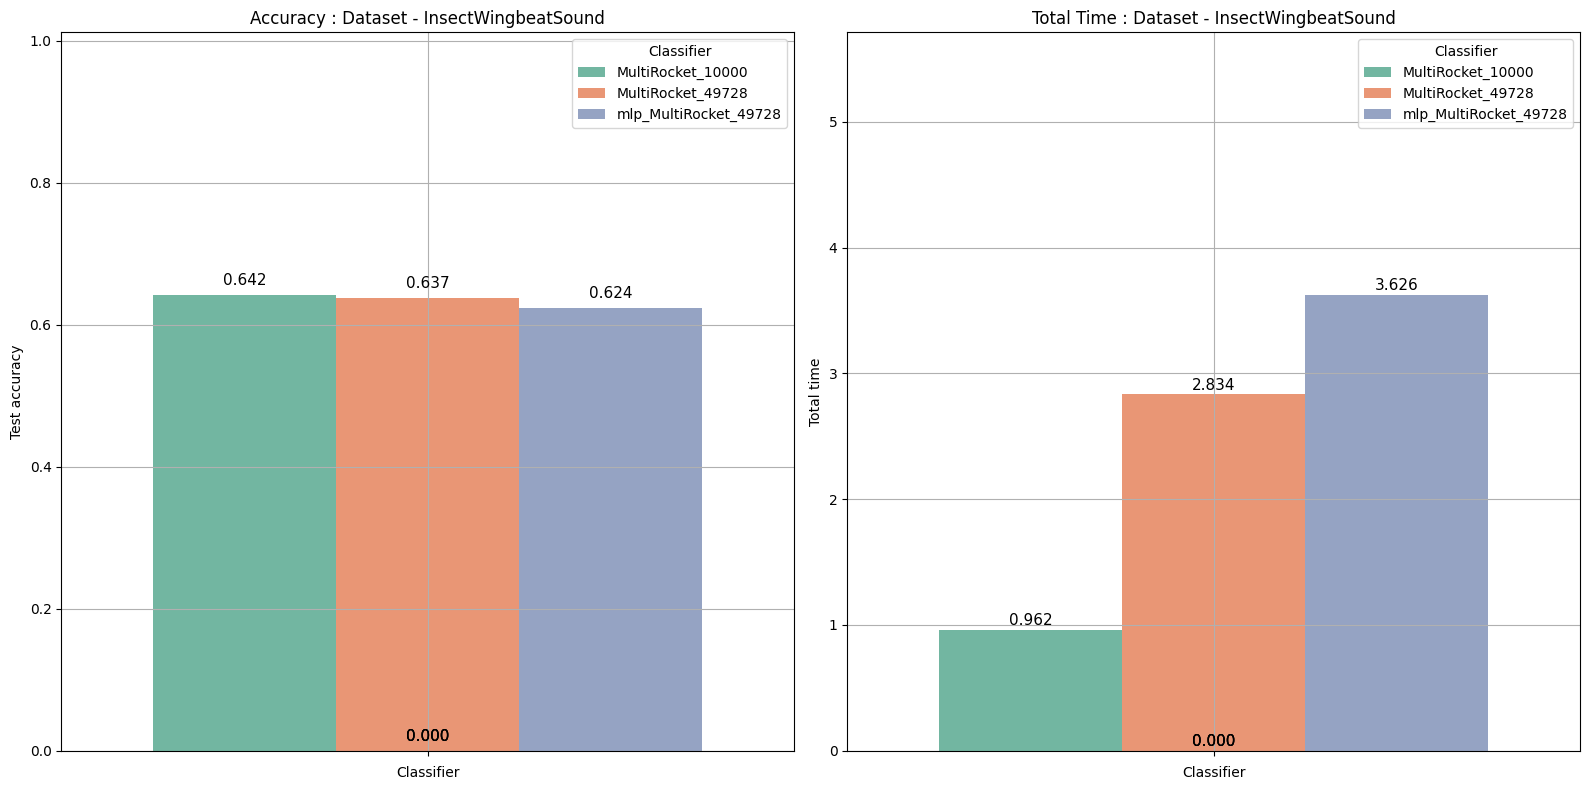

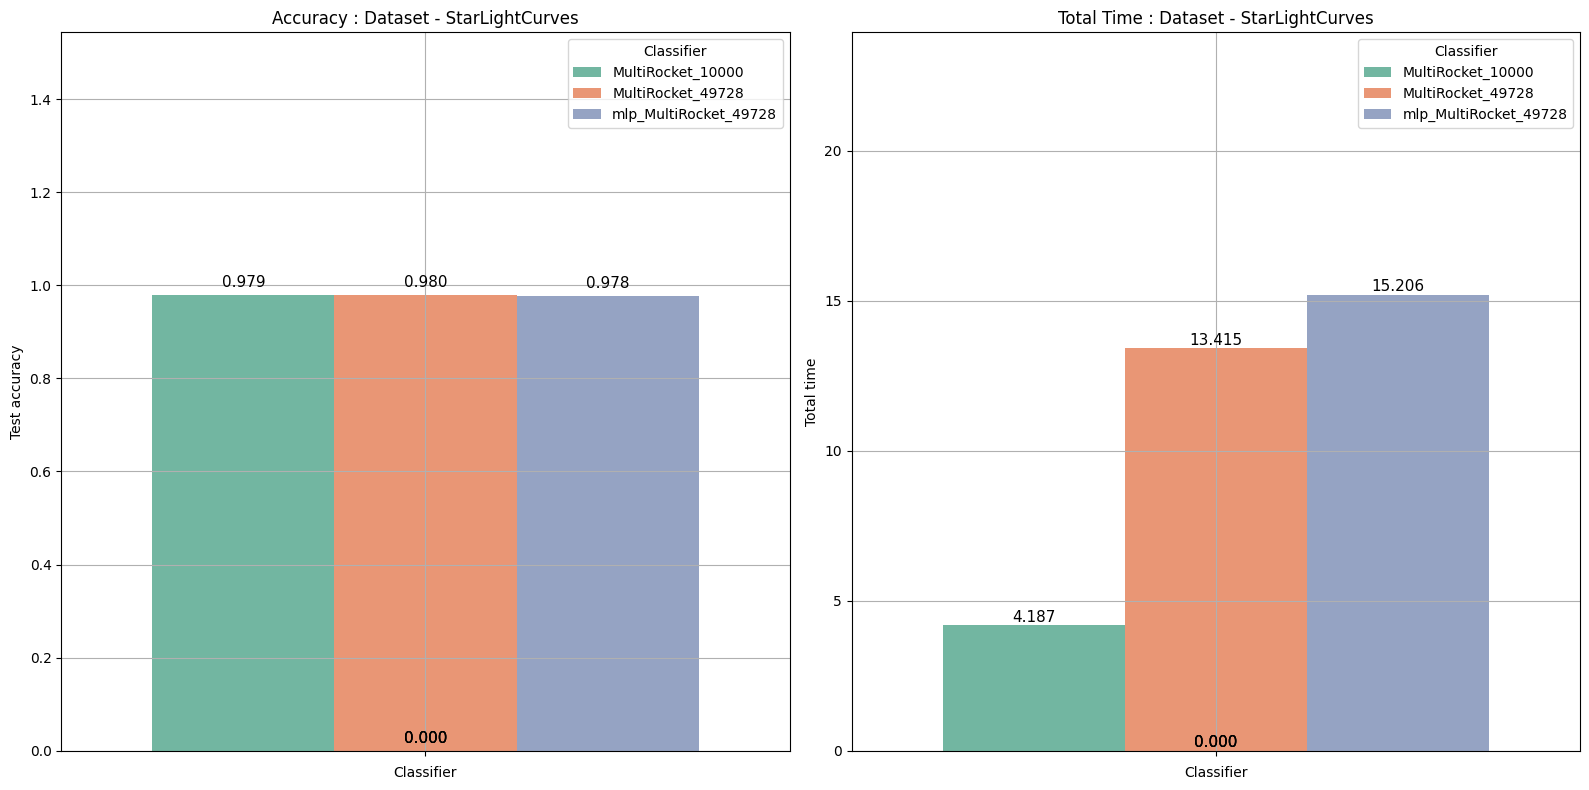

In [4]:
df_v2 = df.copy()

df_v2 = df_v2[~df_v2['classifier'].str.contains('skew|var')]

# Display
display(df_v2.head(20))

for dataset in df_v2['dataset'].unique():

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v2[df_v2['dataset'] == dataset],
        y='test_acc',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Accuracy : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v2[df_v2['dataset'] == dataset],
        y='total_time',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Total Time : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.tight_layout()
    plt.show()